In [ ]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

In [ ]:
# Rozpakowanie pliku zip
import zipfile
import os

zip_path = "archive.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
# wczytanie pliku csv
csv_path = 'data/chinese_mnist.csv'
df = pd.read_csv(csv_path)

df.head()  # pierwsze wiersze



,suite_id,sample_id,code,value,character
0,1,1,10,9,九
1,1,10,10,9,九
2,1,2,10,9,九
3,1,3,10,9,九
4,1,4,10,9,九


In [ ]:
# Załadowanie obrazów i etykiet
from PIL import Image
from torchvision import transforms
from torch.utils.data import TensorDataset

transform = transforms.ToTensor()
images, labels = [], []
for _, row in df.iterrows():
    filename = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
    img_path = os.path.join("data/data/data", filename)

    image = Image.open(img_path).convert("L")
    image = transform(image)
    label = row['code'] - 1  # 0–14 bo mamy 15 cyfr

    images.append(image)
    labels.append(label)

# Zbuduj dataset
X = torch.stack(images)
y = torch.tensor(labels)
chinese_mnist = TensorDataset(X, y)

In [ ]:
from torch.utils.data import random_split

total_size = len(chinese_mnist)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

chinese_train, chinese_valid, chinese_test = random_split(
    chinese_mnist,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(chinese_train, batch_size, shuffle=True)
valid_dl = DataLoader(chinese_valid, batch_size, shuffle=False)
test_dl = DataLoader(chinese_test, batch_size, shuffle=False)

In [ ]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1, 16, kernel_size=3, padding=1))
model.add_module('batch1', nn.BatchNorm2d(16))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))  # 64 -> 32

model.add_module('conv2', nn.Conv2d(16, 32, kernel_size=3, padding=1))
model.add_module('batch2', nn.BatchNorm2d(32))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))  # 32 -> 16

model.add_module('flatten', nn.Flatten())
model.add_module('fc1', nn.Linear(32 * 16 * 16, 1024))  # 8192
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.5))
model.add_module('fc2', nn.Linear(1024, 15))  # 15 klas

In [ ]:
model1 =nn.Sequential()
model1.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding=1))
model1.add_module('batch1', nn.BatchNorm2d(32))
model1.add_module('relu1', nn.ReLU())
model1.add_module('pool1', nn.MaxPool2d(2))  # 64 -> 32

model1.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding=1))
model1.add_module('batch2', nn.BatchNorm2d(64))
model1.add_module('relu2', nn.ReLU())
model1.add_module('pool2', nn.MaxPool2d(2))  # 32 -> 16

model1.add_module('conv3', nn.Conv2d(64, 128, kernel_size=3, padding=1))
model1.add_module('batch3', nn.BatchNorm2d(128))
model1.add_module('relu3', nn.ReLU())
model1.add_module('pool3', nn.MaxPool2d(2))

model1.add_module('conv4', nn.Conv2d(128,256, kernel_size=3, padding=1))
model1.add_module('batch4', nn.BatchNorm2d(256))
model1.add_module('relu4', nn.ReLU())

model1.add_module('flatten', nn.Flatten())
model1.add_module('fc1', nn.Linear(256 * 8 * 8, 1024))  # 8192
model1.add_module('relu5', nn.ReLU())
model1.add_module('dropout', nn.Dropout(0.5))
model1.add_module('fc2', nn.Linear(1024, 15))  # 15 klas

In [ ]:
import torch.nn as nn

model_2 = nn.Sequential()

model_2.add_module('conv1', nn.Conv2d(1, 32, kernel_size=5, padding=2))
model_2.add_module('relu1', nn.ReLU())
model_2.add_module('pool1', nn.MaxPool2d(2))

model_2.add_module('conv2', nn.Conv2d(32, 48, kernel_size=3, padding=1, stride=2))
model_2.add_module('leaky1', nn.LeakyReLU())
model_2.add_module('pool2', nn.MaxPool2d(2))

model_2.add_module('conv3', nn.Conv2d(48, 256, kernel_size=3, padding=1))
model_2.add_module('batch1', nn.BatchNorm2d(256))
model_2.add_module('relu2', nn.ReLU())

model_2.add_module('flatten', nn.Flatten())
model_2.add_module('fc1', nn.Linear(256 * 8 * 8, 128))
model_2.add_module('relu3', nn.ReLU())
model_2.add_module('dropout', nn.Dropout(0.5))
model_2.add_module('fc2', nn.Linear(128, 15))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model1 = model1.to(device)
model_2= model_2.to(device)

In [ ]:
# Słownik z modelami i nazwami
model_configs = {
    "medium": model,
    "best": model1,
    "worst": model_2
}

results = {}

In [ ]:
def train(model, optimizer, num_epochs, train_dl, valid_dl):
    loss_fn = nn.CrossEntropyLoss()
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'[{model_name}] Epoch {epoch+1} acc: {accuracy_hist_train[epoch]:.4f} val_acc: {accuracy_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


In [ ]:
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import time

def timed_train(train_func, *args, **kwargs):
    start = time.time()
    history = train_func(*args, **kwargs)
    end = time.time()
    elapsed = end - start
    return history, elapsed

results = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10

for model_name, model in model_configs.items():
    print(f"\n Trening modelu: {model_name}")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    history, elapsed = timed_train(train, model, optimizer, num_epochs, train_dl, valid_dl)

    results[model_name] = {
        "model": model,
        "history": history,
        "time": elapsed
    }



🔧 Trening modelu: baseline
[baseline] Epoch 1 acc: 0.6713 val_acc: 0.8707
[baseline] Epoch 2 acc: 0.8938 val_acc: 0.9207
[baseline] Epoch 3 acc: 0.9348 val_acc: 0.9500
[baseline] Epoch 4 acc: 0.9499 val_acc: 0.9547
[baseline] Epoch 5 acc: 0.9602 val_acc: 0.9580
[baseline] Epoch 6 acc: 0.9676 val_acc: 0.9547
[baseline] Epoch 7 acc: 0.9725 val_acc: 0.9213
[baseline] Epoch 8 acc: 0.9779 val_acc: 0.9673
[baseline] Epoch 9 acc: 0.9802 val_acc: 0.9633
[baseline] Epoch 10 acc: 0.9825 val_acc: 0.9653

🔧 Trening modelu: improved
[improved] Epoch 1 acc: 0.8143 val_acc: 0.9340
[improved] Epoch 2 acc: 0.9574 val_acc: 0.9327
[improved] Epoch 3 acc: 0.9743 val_acc: 0.8947
[improved] Epoch 4 acc: 0.9783 val_acc: 0.9540
[improved] Epoch 5 acc: 0.9835 val_acc: 0.9200
[improved] Epoch 6 acc: 0.9861 val_acc: 0.9787
[improved] Epoch 7 acc: 0.9823 val_acc: 0.9453
[improved] Epoch 8 acc: 0.9833 val_acc: 0.9860
[improved] Epoch 9 acc: 0.9902 val_acc: 0.9893
[improved] Epoch 10 acc: 0.9902 val_acc: 0.9907

🔧

In [ ]:
models = {
    "Model A": model,
    "Model B": model1,
    "Model C": model_2
}

for name, m in models.items():
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_dl:
            images = images.to(device)
            labels = labels.to(device)

            preds = m(images)
            predicted = torch.argmax(preds, dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"{name} - Test accuracy: {accuracy:.4f}")

Model A - Test accuracy: 0.9707
Model B - Test accuracy: 0.9960
Model C - Test accuracy: 0.9707


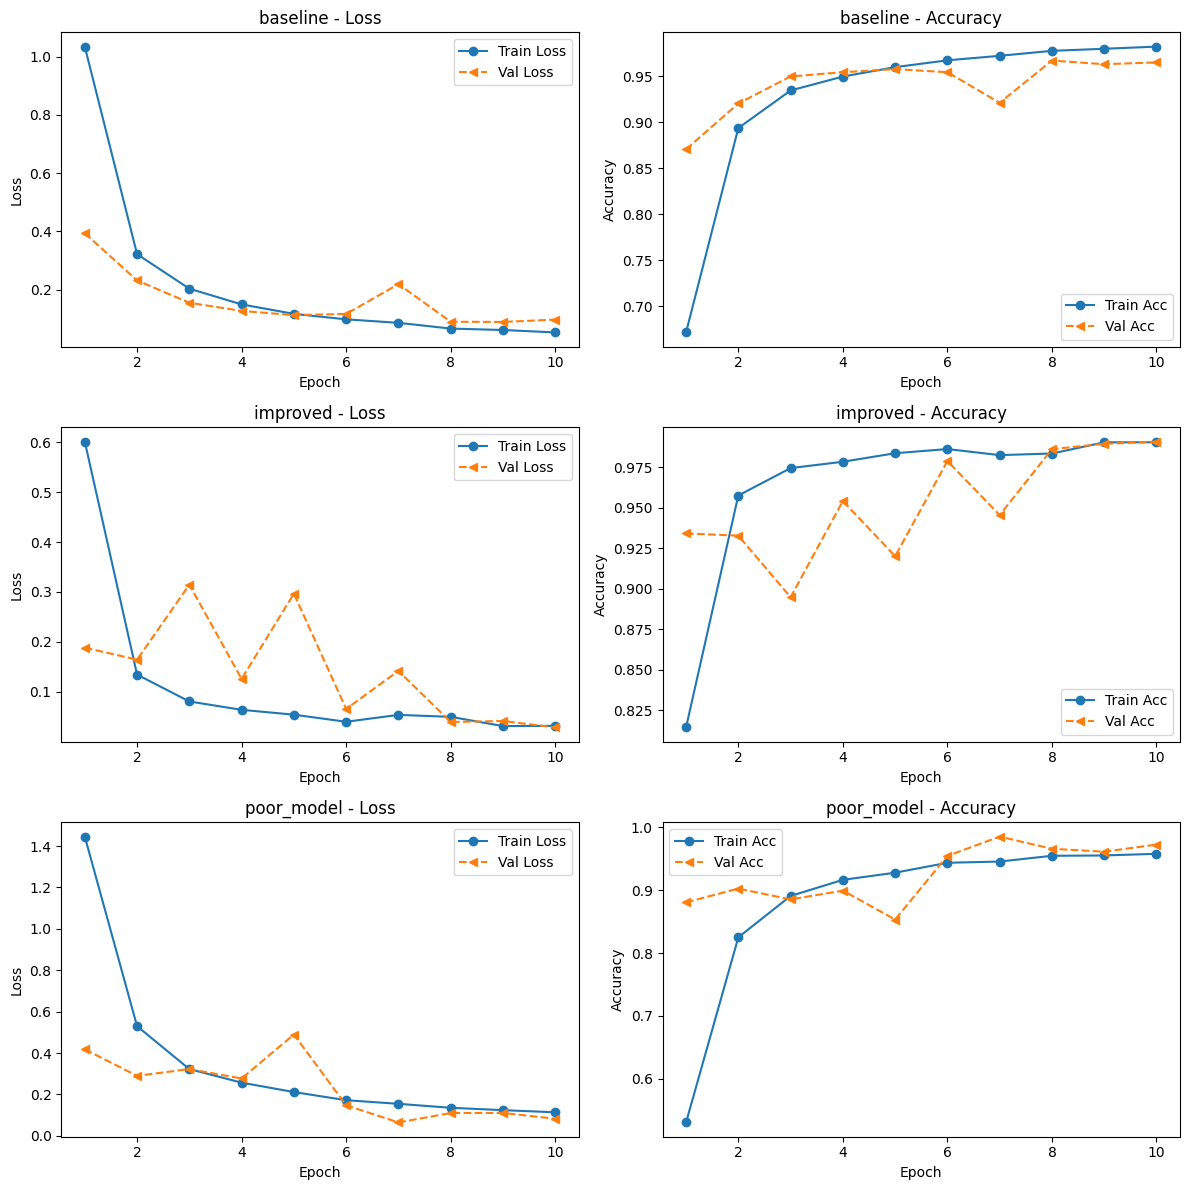

In [ ]:
hists = {model_name: result["history"] for model_name, result in results.items()}

epochs = np.arange(len(next(iter(hists.values()))[0])) + 1

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for idx, (model_name, hist) in enumerate(hists.items()):
    # Wiersz idx — kolumna 0: loss
    axs[idx, 0].plot(epochs, hist[0], '-o', label='Train Loss')
    axs[idx, 0].plot(epochs, hist[1], '--<', label='Val Loss')
    axs[idx, 0].set_title(f'{model_name} - Loss')
    axs[idx, 0].set_xlabel('Epoch')
    axs[idx, 0].set_ylabel('Loss')
    axs[idx, 0].legend()

    # Wiersz idx — kolumna 1: accuracy
    axs[idx, 1].plot(epochs, hist[2], '-o', label='Train Acc')
    axs[idx, 1].plot(epochs, hist[3], '--<', label='Val Acc')
    axs[idx, 1].set_title(f'{model_name} - Accuracy')
    axs[idx, 1].set_xlabel('Epoch')
    axs[idx, 1].set_ylabel('Accuracy')
    axs[idx, 1].legend()

plt.tight_layout()
plt.show()

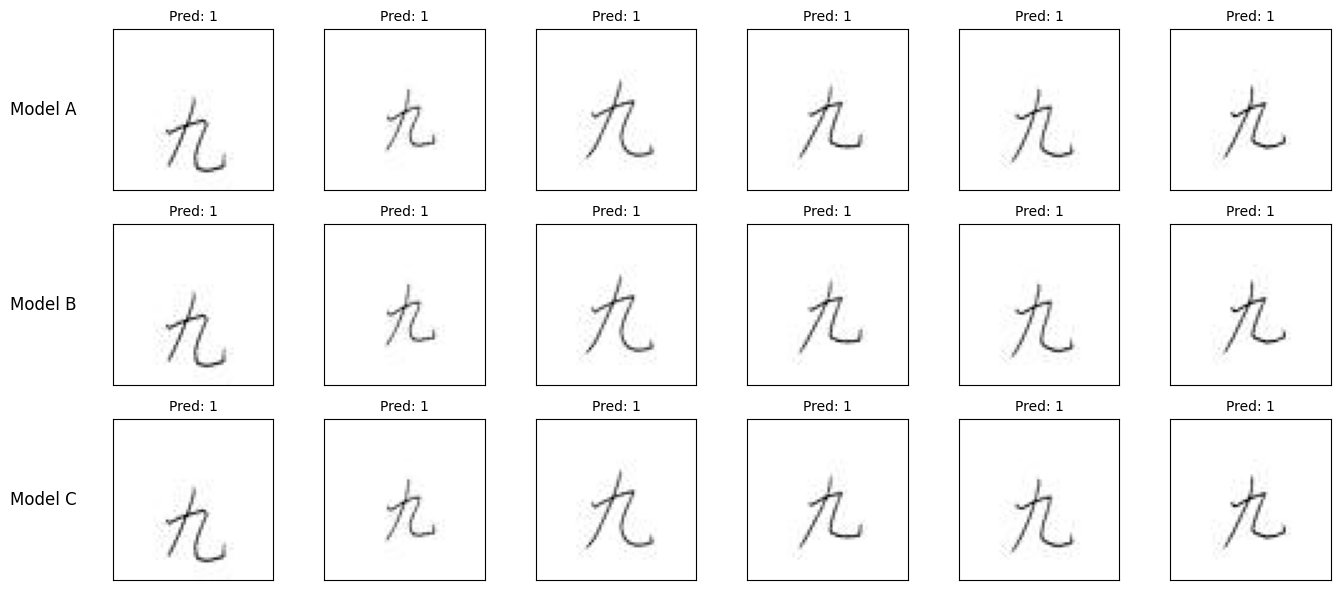

In [ ]:
models = {
    "Model A": model,
    "Model B": model1,
    "Model C": model_2
}

n_images = 6
sample_indices = range(n_images)

fig, axs = plt.subplots(nrows=len(models), ncols=n_images, figsize=(14, 6))
plt.subplots_adjust(hspace=0.3)

for row, (name, m) in enumerate(models.items()):
    m.eval()
    for col, idx in enumerate(sample_indices):
        img_tensor, true_label = chinese_mnist[idx]

        img_input = img_tensor.unsqueeze(0).float().to(device) / 255.

        with torch.no_grad():
            pred = m(img_input)
            y_pred = torch.argmax(pred, dim=1).item()

        ax = axs[row, col] if len(models) > 1 else axs[col]
        ax.imshow(img_tensor[0], cmap='gray_r')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Pred: {y_pred}", fontsize=10)

        if col == 0:
            ax.set_ylabel(name, rotation=0, size=12, labelpad=50, va='center')

plt.tight_layout()
plt.show()

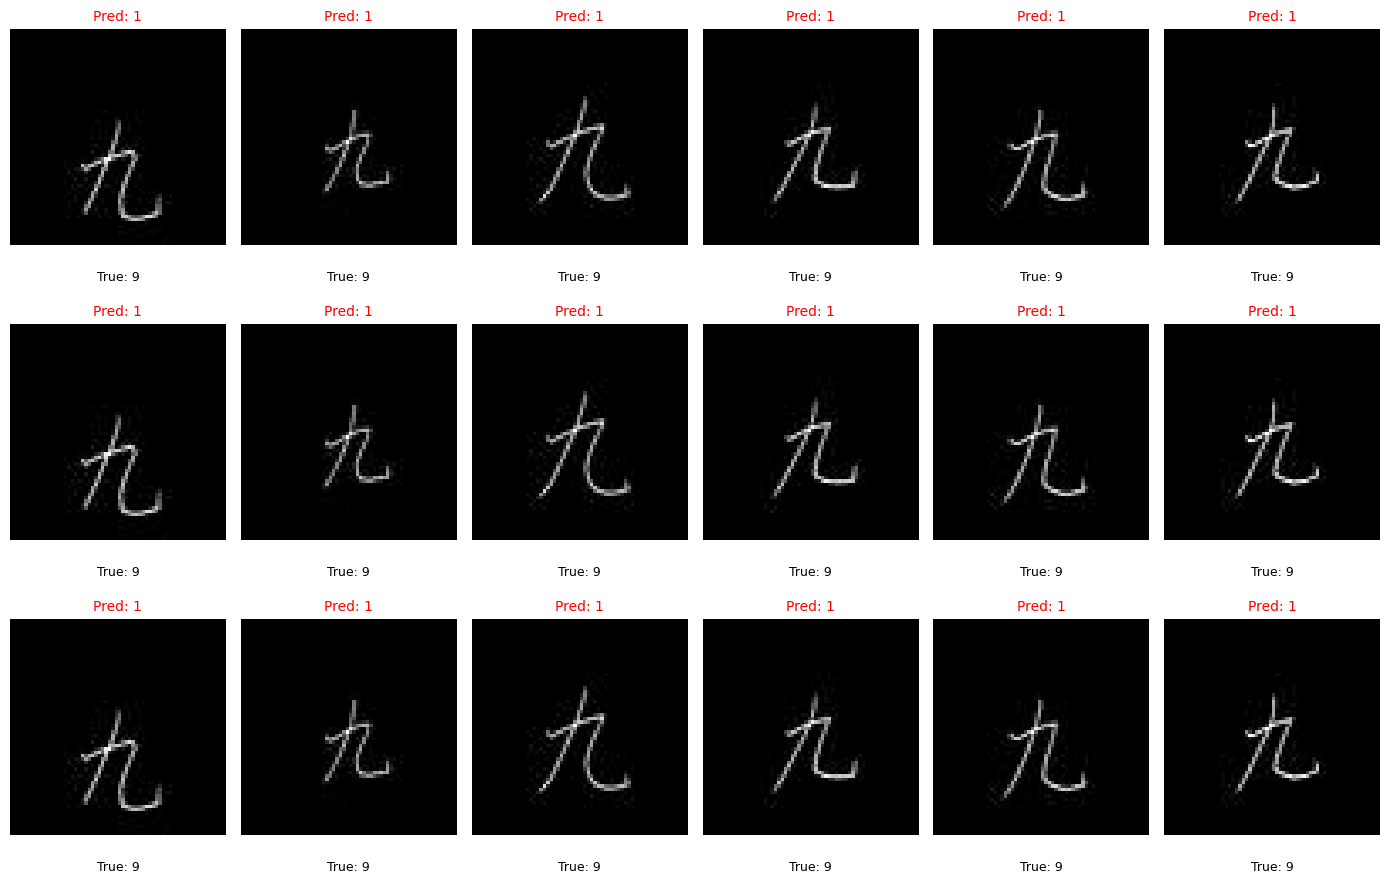

In [ ]:
models = {
    "Model A": model,
    "Model B": model1,
    "Model C": model_2
}

n_rows = len(models)
n_cols = 6

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 3 * n_rows))
plt.subplots_adjust(hspace=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for row, (model_name, m) in enumerate(models.items()):
    m.eval()
    m.to(device)

    incorrect = 0
    idx = 0

    while incorrect < n_cols and idx < len(chinese_mnist):
        img, label = chinese_mnist[idx]
        img_input = img.unsqueeze(0).float().to(device) / 255.

        with torch.no_grad():
            pred = m(img_input)
            y_pred = torch.argmax(pred)

        if y_pred != label:
            ax = axs[row, incorrect] if n_rows > 1 else axs[incorrect]
            ax.imshow(img[0], cmap='gray')
            ax.axis('off')
            ax.set_title(f"Pred: {y_pred.item()}", color='red', fontsize=10)
            ax.text(0.5, -0.15, f'True: {label}', size=9, color='black',
                    ha='center', va='center', transform=ax.transAxes)
            if incorrect == 0:
                ax.set_ylabel(model_name, rotation=0, size=12, labelpad=50, va='center')
            incorrect += 1

        idx += 1

plt.tight_layout()
plt.show()

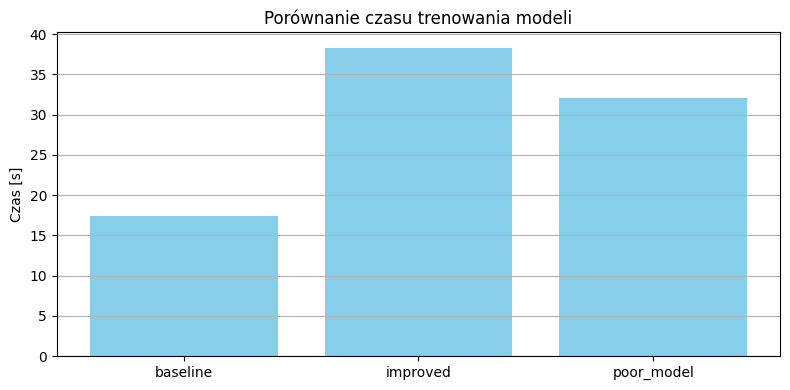

In [ ]:
model_names = list(results.keys())
times = [results[name]["time"] for name in model_names]

plt.figure(figsize=(8, 4))
plt.bar(model_names, times, color='skyblue')
plt.ylabel("Czas [s]")
plt.title("Porównanie czasu trenowania modeli")
plt.grid(axis='y')
plt.tight_layout()
plt.show()